In [1]:
%config InlineBackend.figure_format = 'retina'

import os
import time
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm, TwoSlopeNorm
from pprint import pprint

from coolest.api.analysis import Analysis
from coolest.api.plotting import ModelPlotter, MultiModelPlotter
from coolest.api import util
from coolest.api import plot_util as plut
from coolest.api.composable_models import ComposableLensModel

Template file 'c:\Users\aaang\OneDrive - Northeastern University\Schoolwork\CUNY\Research\COOLEST\docs\notebooks\database\dmr_corner\ErVsZ\sis_tempz1.5RatioTest_pyAPI.json' not found, now trying to read 'c:\Users\aaang\OneDrive - Northeastern University\Schoolwork\CUNY\Research\COOLEST\docs\notebooks\database\dmr_corner\ErVsZ\sis_tempz1.5RatioTest.json'.


C:\Users\aaang\OneDrive - Northeastern University\Schoolwork\CUNY\Research\COOLEST\coolest\template\json.py:524: UserWarning: Warning: the galaxy 'a lens galaxy' has a mass model, hence it is likely a lens galaxy. Setting 'lensed' to False.
  warnings.warn(f"Warning: the galaxy '{entity['name']}' has a mass model, hence it is likely a lens galaxy. Setting 'lensed' to False.")
C:\Users\aaang\OneDrive - Northeastern University\Schoolwork\CUNY\Research\COOLEST\coolest\template\json.py:524: UserWarning: Warning: the galaxy 'a lens galaxy2' has a mass model, hence it is likely a lens galaxy. Setting 'lensed' to False.
  warnings.warn(f"Warning: the galaxy '{entity['name']}' has a mass model, hence it is likely a lens galaxy. Setting 'lensed' to False.")
C:\Users\aaang\OneDrive - Northeastern University\Schoolwork\CUNY\Research\COOLEST\coolest\template\json.py:527: UserWarning: Warning: the galaxy 'a source galaxy' does not have a mass model, hence it is likely a source galaxy. Setting 'lens

Image radii:  3.0 1.0
M Ratio:  0.8699273321721898
D Ratio:  1.056678423157315


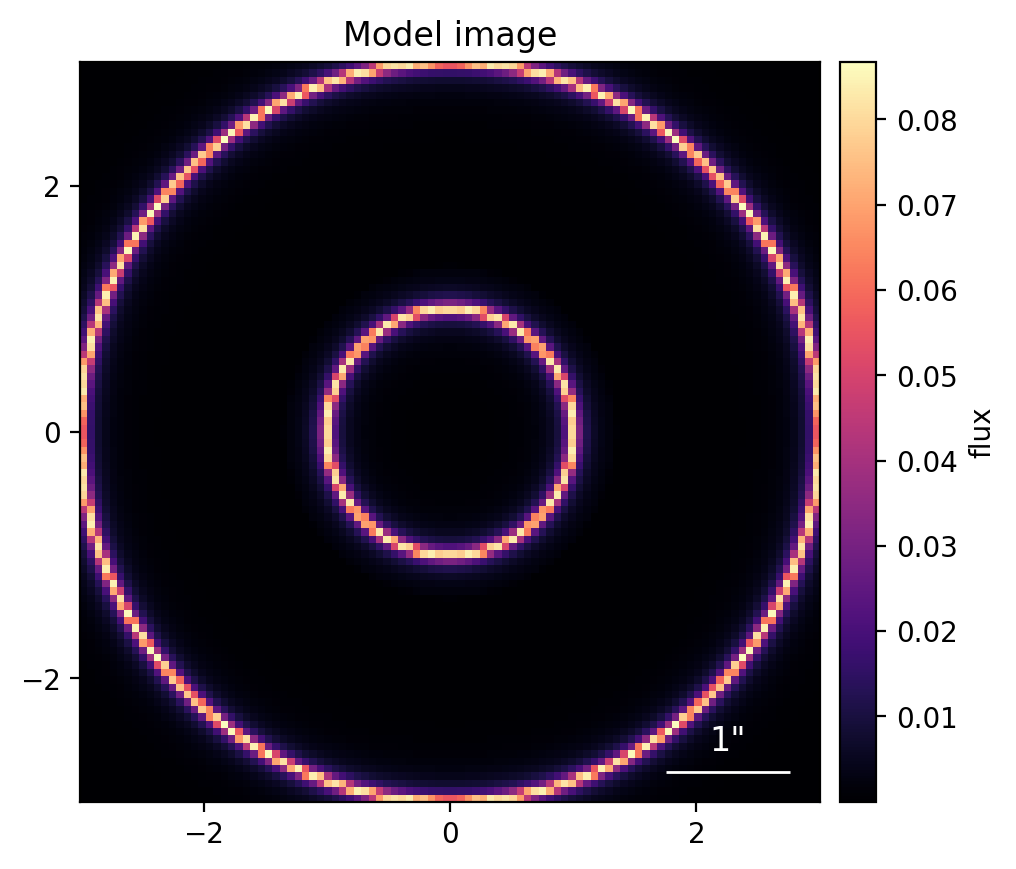

In [4]:

code_1_path = 'database/dmr_corner/ErVsZ/sis_tempz1.5RatioTest'
coolest_1 = util.get_coolest_object(code_1_path, verbose=True, check_external_files=False)

splotter = ModelPlotter(coolest_1, coolest_directory=os.path.dirname(code_1_path))
plt.figure()
ax = plt.gca()
splotter.plot_model_image(
    title ='Model image', ax = ax, convolved = False, auto_selection = True
)


# Theory test:
# M = theta_E / (D_ds/D_s)

theta_E1 = 2
theta_E2 = 1

z1 = 1
z2 = 1.5
z3 = 2

from astropy.cosmology import FlatLambdaCDM

cm = FlatLambdaCDM(
        H0=73.0,
        Om0=0.3)

D_13  = cm.angular_diameter_distance_z1z2(z1,z3)
D_23  = cm.angular_diameter_distance_z1z2(z2,z3)
D_3 = cm.angular_diameter_distance(z3)

D_1 = cm.angular_diameter_distance(z1)
D_2 = cm.angular_diameter_distance(z2)

M1 = theta_E1/(D_13/D_3)
M2 = theta_E2/(D_23/D_3)

image_E1 = (M1 * D_13 + M2 * D_23)/D_3
image_E2 = (M1 * D_13 - M2 * D_23)/D_3

print('Image radii: ', image_E1, image_E2)

print('M Ratio: ', M1/M2)
print('D Ratio: ', D_2/D_1)

In [5]:
print('M Ratio: ', M1/M2)
print('D Ratio: ', D_2/D_1)


def plot_ray_path(model, x_img, y_img):
    """
    Plot the path of a ray from image plane back through lens planes to source plane.
    For multi-plane lensing, this shows the position at each plane.
    """
    x_img = float(x_img)
    y_img = float(y_img)

    import copy
    cosmology = model.coolest.cosmology
    
    # If no mass planes, just plot the image position
    if not hasattr(model, 'lens_mass_sorted') or len(model.lens_mass_sorted) == 0:
        redshifts = [0]
        x_positions = [x_img]
        y_positions = [y_img]
    else:
        # Representative entity name for each mass plane
        plane_names = [model.coolest.lensing_entities[group[0]].name for group in model.mass_entity_indexes_sorted]
        
        # Coordinates at each plane: index 0 is observed plane
        x_def = [x_img]
        y_def = [y_img]
        
        n_planes = len(model.lens_mass_sorted)
        # Compute coordinates at successive mass planes (forward ray shooting positions)
        for j in range(n_planes):
            x_def_temp = x_def[0]
            y_def_temp = y_def[0]
            for i in range(j):
                from_name = plane_names[i]
                to_name = plane_names[j]
                beta = model.coolest.multiplane_betas.resolve_beta(from_name, to_name, model.coolest.lensing_entities, cosmology)
                ax, ay = model.lens_mass_sorted[i].evaluate_deflection(x_def[i+1], y_def[i+1])
                x_def_temp -= beta * ax
                y_def_temp -= beta * ay
            x_def.append(x_def_temp)
            y_def.append(y_def_temp)
        
        # Redshifts: observer + mass planes
        redshifts = [0] + model.mass_redshifts_sorted
        
        x_positions = x_def
        y_positions = y_def
        
        # If there are sources, add the source position
        if hasattr(model, 'source_sorted') and len(model.source_sorted) > 0:
            # For simplicity, take the first source
            z_src = model.source_redshifts_sorted[0]
            prior_planes = [k for k, z in enumerate(model.mass_redshifts_sorted) if z < z_src]
            if len(prior_planes) == 0:
                x_src = x_img
                y_src = y_img
            else:
                rs_index = prior_planes[-1]
                x_src = x_def[0]
                y_src = y_def[0]
                # Resolve source name
                src_entity_sel = model.source_entity_indexes_sorted[0]
                if src_entity_sel is None:
                    src_name = model.source_sorted[0].info_list[0][0]
                else:
                    if isinstance(src_entity_sel, (list, tuple)):
                        src_idx = src_entity_sel[0]
                    else:
                        src_idx = src_entity_sel
                    src_name = model.coolest.lensing_entities[src_idx].name
                
                for i in range(rs_index + 1):
                    from_name = plane_names[i]
                    beta = model.coolest.multiplane_betas.resolve_beta(from_name, src_name, model.coolest.lensing_entities, cosmology)
                    ax, ay = model.lens_mass_sorted[i].evaluate_deflection(x_def[i+1], y_def[i+1])
                    x_src -= beta * ax
                    y_src -= beta * ay
            
            redshifts.append(z_src)
            x_positions.append(x_src)
            y_positions.append(y_src)
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(redshifts, x_positions, 'o-', label='x position')
    ax1.set_xlabel('Redshift')
    ax1.set_ylabel('x position')
    ax1.set_title(f'Ray path x for image pixel ({x_img:.3f}, {y_img:.3f})')
    ax1.grid(True)
    
    ax2.plot(redshifts, y_positions, 's-', label='y position', color='orange')
    ax2.set_xlabel('Redshift')
    ax2.set_ylabel('y position')
    ax2.set_title(f'Ray path y for image pixel ({x_img:.3f}, {y_img:.3f})')
    ax2.grid(True)

    min_y_ax = min(min(x_positions), min(y_positions))
    max_y_ax = max(max(x_positions), max(y_positions))
    ax1.set_ylim(min_y_ax - 0.1, max_y_ax + 0.1)
    ax2.set_ylim(min_y_ax - 0.1, max_y_ax + 0.1)
    
    plt.tight_layout()
    plt.show()

    plt.figure()
    colors = ['red', 'green', 'blue']
    for i in range(len(redshifts)-1):
        plt.scatter(x_positions[i+1], y_positions[i+1], c=colors[i], alpha = 0.5)
    plt.grid(True)
    plt.xlim(-5,5)
    plt.ylim(-5,5)
    plt.xlabel('x position')
    plt.ylabel('y position')
    plt.title('Ray mapping across redshift')
    plt.legend(['z = ' + str(z) for z in redshifts[1:]])

    circle1 = plt.Circle((0, 0), image_E1, color='orange', fill=False, linewidth=2)
    circle2 = plt.Circle((0, 0), image_E2, color='orange', fill=False, linewidth=2)

    ax = plt.gca()
    ax.add_patch(circle1)
    ax.add_patch(circle2)

    ax.set_aspect('equal')

    plt.show()

    return redshifts, x_positions, y_positions


# Test the function with a pixel not at center
model = ComposableLensModel(coolest_1, coolest_directory=os.path.dirname(code_1_path))
plot_ray_path(model, -1, 0)

M Ratio:  0.8699273321721898
D Ratio:  1.056678423157315


ValueError: Cannot parse redshifts from IDs: a lens galaxy, a lens galaxy2

In [6]:
def plot_ray_grid(model, n):
    import colorsys
    from astropy.cosmology import FlatLambdaCDM
    
    # Grid points
    nx, ny = n, n
    x_vals = np.linspace(-3, 3, nx)
    y_vals = np.linspace(-3, 3, ny)
    points = [(x, y) for x in x_vals for y in y_vals]
    
    # Colors: 2D gradient
    x_min, x_max = -3, 3
    y_min, y_max = -3, 3
    colors = []
    for x, y in points:
        x_norm = (x - x_min) / (x_max - x_min) * 0.9
        y_norm = (y - y_min) / (y_max - y_min) * 0.9
        h = x_norm  # hue varies with x
        s = y_norm  # saturation varies with y
        v = 1
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        colors.append((r, g, b))
    
    # Compute positions backwards through planes
    if not hasattr(model, 'lens_mass_sorted') or len(model.lens_mass_sorted) == 0:
        redshifts = [0]
        all_x = [[x for x, y in points]]
        all_y = [[y for x, y in points]]
    else:
        redshifts = [0] + model.mass_redshifts_sorted
        all_x = [[x for x, y in points]]
        all_y = [[y for x, y in points]]
        plane_names = [model.coolest.lensing_entities[group[0]].name for group in model.mass_entity_indexes_sorted]
        
        for i in range(len(model.lens_mass_sorted)):
            x_new_list = []
            y_new_list = []
            for k, (x_img, y_img) in enumerate(points):
                x_prev = all_x[-1][k]
                y_prev = all_y[-1][k]
                ax, ay = model.lens_mass_sorted[i].evaluate_deflection(x_prev, y_prev)
                if i == 0:
                    # For first lens, use beta=1 as fallback
                    beta = 1
                else:
                    from_name = plane_names[i-1]
                    to_name = plane_names[i]
                    beta = model.coolest.multiplane_betas.resolve_beta(from_name, to_name, model.coolest.cosmology)
                x_new = x_prev - beta * ax
                y_new = y_prev - beta * ay
                x_new_list.append(x_new)
                y_new_list.append(y_new)
            all_x.append(x_new_list)
            all_y.append(y_new_list)
    
    # Add source plane if exists
    if hasattr(model, 'source_sorted') and len(model.source_sorted) > 0:
        z_src = model.source_redshifts_sorted[0]
        prior_indices = [k for k, z in enumerate(model.mass_redshifts_sorted) if z < z_src]
        if len(prior_indices) == 0:
            x_src_list = [x for x, y in points]
            y_src_list = [y for x, y in points]
        else:
            rs_index = prior_indices[-1]
            x_src_list = []
            y_src_list = []
            src_entity_sel = model.source_entity_indexes_sorted[0]
            if src_entity_sel is None:
                src_name = model.source_sorted[0].info_list[0][0]
            else:
                if isinstance(src_entity_sel, (list, tuple)):
                    src_idx = src_entity_sel[0]
                else:
                    src_idx = src_entity_sel
                src_name = model.coolest.lensing_entities[src_idx].name
            
            for k, (x_img, y_img) in enumerate(points):
                x_current = all_x[rs_index + 1][k]
                y_current = all_y[rs_index + 1][k]
                for i in range(rs_index + 1, len(model.lens_mass_sorted)):
                    ax, ay = model.lens_mass_sorted[i].evaluate_deflection(x_current, y_current)
                    from_name = plane_names[i]
                    beta = model.coolest.multiplane_betas.resolve_beta(from_name, src_name, model.coolest.cosmology)
                    x_current -= beta * ax
                    y_current -= beta * ay
                x_src_list.append(x_current)
                y_src_list.append(y_current)
        redshifts.append(z_src)
        all_x.append(x_src_list)
        all_y.append(y_src_list)
    
    # Calculate Einstein radii for circles (from the notebook's theory test)
    theta_E1 = 2
    theta_E2 = 1
    z1 = 1
    z2 = 1.5
    z3 = 2
    cm = FlatLambdaCDM(H0=73.0, Om0=0.3)
    D_13 = cm.angular_diameter_distance_z1z2(z1, z3)
    D_23 = cm.angular_diameter_distance_z1z2(z2, z3)
    D_3 = cm.angular_diameter_distance(z3)
    M1 = theta_E1 / (D_13 / D_3)
    M2 = theta_E2 / (D_23 / D_3)
    image_E1 = (M1 * D_13 + M2 * D_23) / D_3
    image_E2 = (M1 * D_13 - M2 * D_23) / D_3
    
    # Plot each plane
    for p in range(len(redshifts)):
        plt.figure(figsize=(6, 6))
        plt.scatter(all_x[p], all_y[p], c=colors, s=20, edgecolors='none')
        plt.xlabel('x position')
        plt.ylabel('y position')
        plt.title(f'Ray positions at z = {redshifts[p]}')
        plt.grid(True)
        plt.axis('equal')
        plt.xlim(-5, 5)
        plt.ylim(-5, 5)
        if p == 0:  # Image plane
            circle1 = plt.Circle((0, 0), image_E1, color='orange', fill=False, linewidth=2)
            circle2 = plt.Circle((0, 0), image_E2, color='orange', fill=False, linewidth=2)
            ax = plt.gca()
            ax.add_patch(circle1)
            ax.add_patch(circle2)
        plt.show()

# Test the new function
plot_ray_grid(model, n=20)

TypeError: MultiPlaneBetaList.resolve_beta() missing 1 required positional argument: 'cosmology'